 ## Note
 **線形SVMの考え方**: パーセプトロンの決定境界$ w \cdot x + b = 0 $に対して以下のマージン境界を導入する
 $$ \begin{align*}
 w \cdot x + b &= 1 \\
 w \cdot x + b &= -1
 \end{align*} $$
 この時、マージン境界間の距離は決定境界を挟んで
 $$\frac{2}{\|w\|}$$
 距離を最大化し、データを決定境界から離すように最適化するモデル

 $2/\|w\|$の最大化は、$\|w|\|$の最小化問題となるため、以下の最適化を行う
 $$ \min_{w,b} \frac{1}{2} \|w\|^2 $$
 また、すべてのサンプルを正しく分類することを制約としている
 $$ y(w \cdot x_i + b) \geq 1 $$

 ここで、現実的にすべてのサンプルを正しく分類する制約を満たせない場合を考慮し
 スラック変数$\xi$を用いて
 $$ \begin{align*}
 &y(w \cdot x_i + b) \geq 1 - \xi_i \\
 &\xi_i \geq 0
 \end{align*} $$
 と条件を緩和する(マージン内への侵入や誤分類を許容する)と、
 以下の最適化問題となる
 $$ \begin{align*}
 &\min_{w,b} \frac{1}{2} \|w\|^2 + C \sum \xi_i \\
 &\text{s.t.} \quad y(w \cdot x_i + b) \geq 1 - \xi_i \\
 &\phantom{\text{s.t.}} \qquad\qquad\quad \xi_i \geq 0
 \end{align*} $$
 memo: マージンに入ることを許容するが、ペナルティになるためできるだけ少なくする

 **ヒンジロスの導入:** 制約 $ y(w \cdot x_i + b) \geq 1 - \xi_i $を変形する
 $$ \xi_i \geq 1 - y_i(w \cdot x_i+b) $$
 ここで、もうひとつの制約 $ \xi_i \geq 0 $により、
 $$ \xi_i = \max(0, 1 - y_i(w \cdot x_i+b)) $$
 となり、右辺がヒンジロスとなっている<br/>
 ここで、スラック変数$\xi$を置き換えると以下の損失関数の最小化問題となる
 $$ J(w, b) = \frac{1}{2} \|w\|^2 + C \sum \max(0, 1 - y_i(w \cdot x_i+b)) $$
 前半は正則化項、後半は損失項となる

 **ヒンジロスでの訓練:** 損失項の値で場合分けして勾配を計算する
 - $y_i(w \cdot x_i+b) > 1$の場合(正しく分類しマージンも1より大きい)
 - $y_i(w \cdot x_i+b) < 1$の場合(誤分類かマージンを確保できていない)
 SGDでの更新則にあてはめると
 $$
 \begin{align*}
 \text{if } &y_i(w \cdot x_i+b) \le 1 \text{  then} \\
 \text{ } &w \leftarrow(1-\eta)w+\eta Cy_ix_i \\
 \text{ } &b \leftarrow b+\eta Cy_i \\
 \text{if } &y_i(w \cdot x_i+b) \gt 1 \text{ then} \\
 \text{ } &w \leftarrow(1-\eta)w,\\
 \text{ } &b \leftarrow b.
 \end{align*}
 $$

In [ ]:
import numpy as np
from IPython.display import display
from numpy.typing import NDArray
from step4_perceptron import (
    Classifier,
    History,
    LogItem,
    TrainLogAnimation,
    init_blobs_dataset,
)


class LinearSupportVectorMachine(Classifier):
    def __init__(
        self,
        ndim: int = 2,
        eta: float = 0.0005,
        C: float = 5,
        tolerance: float = 0.01,
        patience: int = 10,
    ):
        super().__init__(ndim=ndim, eta=eta)
        self.C = C
        self.tolerance = tolerance
        self.patience = patience
        self._convergence_count = 0

    def train(self, Dx: NDArray, Dy: NDArray, epochs: int = 100) -> History:
        history = History(Dx, Dy, epochs)
        history.append(LogItem(self.copy()))

        for i in range(epochs):
            w_old = self.w[:]
            b_old = self.b
            for x_i, y_i in zip(Dx, Dy):
                history.append(LogItem(self.copy(), x_i, y_i))
                self.w, self.b = self._train_step(x_i, y_i)

            delta = self._calculate_delta(w_old, b_old)
            print(f"epoch {i + 1}: {delta = }")
            if self._is_converged(delta):
                break
        return history

    def _calculate_delta(self, w_old: NDArray, b_old: float) -> float:
        delta_w = np.linalg.norm(self.w - w_old)
        delta_b = abs(self.b - b_old)

        return delta_w + delta_b

    def _is_converged(self, delta: float) -> bool:
        if delta < self.tolerance:
            self._convergence_count += 1
        else:
            self._convergence_count = 0

        return self._convergence_count >= self.patience

    def _train_step(self, x: NDArray, y: float) -> tuple[NDArray, float]:
        margin = y * self.score(x)
        if margin <= 1:
            w = (1 - self.eta) * self.w + self.eta * self.C * y * x
            b = self.b + self.eta * self.C * y
        else:
            w = (1 - self.eta) * self.w
            b = self.b
        return (w, b)

epoch 1: delta = np.float64(1.7187630995568017)
epoch 2: delta = np.float64(0.46802736983844384)
epoch 3: delta = np.float64(0.17718309012233746)
epoch 4: delta = np.float64(0.12268830941385839)
epoch 5: delta = np.float64(0.10427326751186569)
epoch 6: delta = np.float64(0.10005107795166635)
epoch 7: delta = np.float64(0.08525762671135659)
epoch 8: delta = np.float64(0.08104200373904746)
epoch 9: delta = np.float64(0.07741371952976006)
epoch 10: delta = np.float64(0.07429094351543734)
epoch 11: delta = np.float64(0.06956518380483609)
epoch 12: delta = np.float64(0.062236325582708474)
epoch 13: delta = np.float64(0.05190796675600679)
epoch 14: delta = np.float64(0.038612602613105854)
epoch 15: delta = np.float64(0.02774234691070458)
epoch 16: delta = np.float64(0.026663649767411937)
epoch 17: delta = np.float64(0.02526800760359441)
epoch 18: delta = np.float64(0.019107424078396124)
epoch 19: delta = np.float64(0.018535160051641242)
epoch 20: delta = np.float64(0.018042626315711657)
epoc

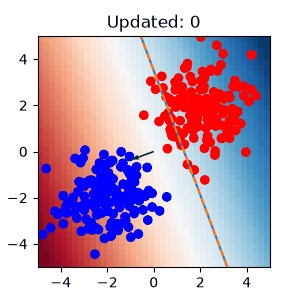

In [ ]:
def main():
    Dx, Dy = init_blobs_dataset(centers=[[2, 2], [-2, -2]])

    model = LinearSupportVectorMachine()
    history = model.train(Dx, Dy)
    output_frames = 150
    frame_sampling_rate = min(1.0, output_frames / len(history))

    log_anim = TrainLogAnimation(
        history,
        xlim=(-5, 5),
        ylim=(-5, 5),
    )
    display(log_anim.plot(figsize=(3, 3), frame_sampling_rate=frame_sampling_rate))


if __name__ == "__main__":
    main()